# Загрузка библиотек и модулей

In [ ]:
# Установка необходимых библиотек для работы бота и парсинга
# ВНИМАНИЕ: Синтаксис с '!' используется в Jupyter Notebook/Google Colab.
# В обычном скрипте запускайте эти команды в терминале без '!'

# Установка aiogram - современного асинхронного фреймворка для Telegram ботов!
!pip install -q aiogram

# Установка aiohttp - библиотеки для асинхронных HTTP-запросов
!pip install -q aiohttp

# Установка requests - популярной синхронной HTTP-библиотеки
!pip install -q requests

# Установка beautifulsoup4 - инструмента для парсинга HTML/XML документов
!pip install -q beautifulsoup4

# Установка fake-useragent - для генерации случайных User-Agent заголовков
# (полезно при парсинге, чтобы избежать блокировок)
!pip install -q fake-useragent

# Рекомендуется создавать виртуальное окружение для проекта,
# чтобы не возникало конфликтов версий библиотек

# Для обычной установки вне Jupyter/Colab используйте в терминале:
# pip install aiogram aiohttp requests beautifulsoup4 fake-useragent

In [ ]:
# Импорт стандартных библиотек
import time  # Работа с временными функциями (задержки, замер времени выполнения)
# 1. time - используется для:
#    - Задержек в синхронном коде (time.sleep)
#    - Замера времени выполнения операций
#    В асинхронном коде предпочтительнее использовать asyncio.sleep

import asyncio  # Асинхронное программирование (корутины, event loop)
# 2. asyncio - основа асинхронной логики:
#    - Event loop (цикл событий)
#    - Управление корутинами
#    - Создание задач (Tasks)
#    - Синхронизация между задачами

import warnings  # Фильтрация и обработка предупреждений Python
# 7. warnings - управление выводом предупреждений:
#    - Отключаем ложные срабатывания BeautifulSoup
#    - Важно для чистоты вывода в продакшене

# Импорт HTTP-библиотек
import requests  # Синхронные HTTP-запросы
# 3. requests + Retry/HTTPAdapter - расширенные HTTP-возможности:
#    - Retry: настройка стратегии повторных запросов при ошибках
#      (например, 3 попытки при 5xx ошибках)
#    - HTTPAdapter: кастомизация соединений (пул соединений, таймауты)
#    Используется для надежных синхронных запросов

from urllib3.util.retry import Retry  # Механизм повторов для запросов
from requests.adapters import HTTPAdapter  # Адаптеры для настройки сессий requests
import aiohttp  # Асинхронные HTTP-запросы
from aiohttp import ClientSession  # Управление асинхронными HTTP-сессиями
# 4. aiohttp - асинхронная альтернатива requests:
#    - ClientSession: контекстный менеджер для HTTP-сессий
#    - Поддержка WebSockets
#    - Асинхронные POST/GET запросы


# Импорт компонентов aiogram для Telegram бота
from aiogram import Bot, Dispatcher, types  # Основные классы фреймворка
from aiogram.filters import Command  # Фильтр для обработки команд (/start и т.д.)
# 5. aiogram компоненты:
#    - Bot: точка входа для взаимодействия с Telegram API
#    - Dispatcher: обработка входящих сообщений
#    - types: типы сообщений (Message, CallbackQuery и т.д.)
#    - Command: обработка команд типа /start

# Импорт парсинговых инструментов
from bs4 import BeautifulSoup  # Парсинг HTML/XML
from fake_useragent import UserAgent  # Генерация случайных User-Agent
from urllib.parse import urljoin  # Обработка относительных URL
from bs4 import MarkupResemblesLocatorWarning  # Фильтрация специфических предупреждений BeautifulSoup
# 6. Парсинг-инструменты:
#    - BeautifulSoup: парсинг HTML через CSS-селекторы/XPath
#    - UserAgent: генерация случайных заголовков User-Agent
#    - urljoin: безопасная склейка URL (относительные → абсолютные)

# Фильтрация предупреждений BeautifulSoup о подозрительной разметке
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

# Особенности использования:
# - Смесь синхронных (requests) и асинхронных (aiohttp) библиотек требует
#   аккуратного использования, чтобы не блокировать event loop
# - Приоритет следует отдавать асинхронным методам в обработчиках бота
# - Для парсинга в продакшене важно добавить:
#   - Таймауты запросов
#   - Обработку ошибок соединения
#   - Рейт-лимитирование
#   - Прокси-поддержку


# Различия синхронного и асинхронного программирования

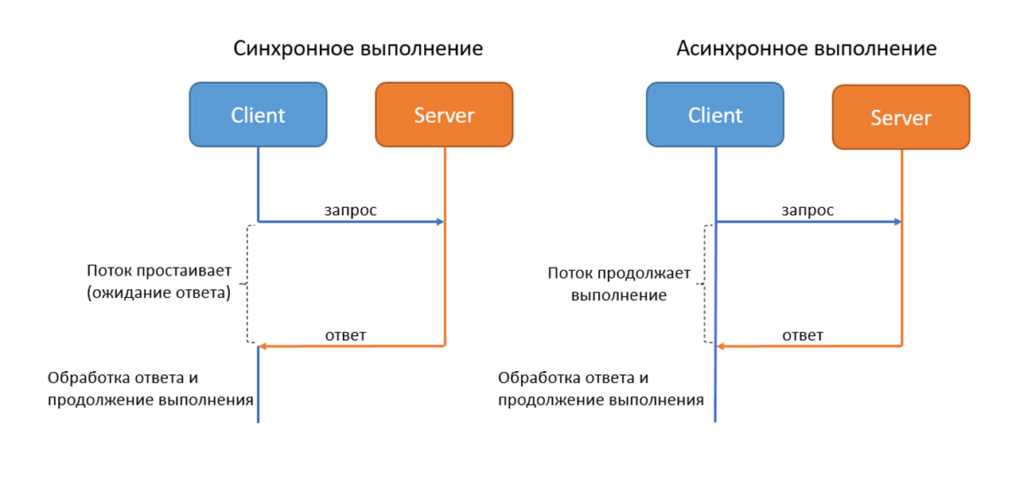

Основное различие между синхронным и асинхронным кодом заключается в следующем.

Синхронный код предполагает выполнение операций последовательно. Если одна операция занимает время (например, запрос к API), весь код «замирает» до её завершения.

Асинхронный код позволяет выполнять задачи параллельно. Пока одна операция ждёт (например, ответа от сервера), другие могут выполняться.

Рассмотрим эту особенность на простых примерах.

## Пример 1

In [ ]:
# Синхронный код

def sync_example():
    print("Начало синхронной задачи")
    time.sleep(5)
    print("Конец синхронной задачи")

sync_example()

Начало синхронной задачи
Конец синхронной задачи


Что происходит:

- Вызывается функция sync_example()

- Печатается "Начало синхронной задачи"

- Программа "засыпает" на 5 секунд (time.sleep(5) блокирует весь поток выполнения)

- Через 5 секунд печатается "Конец синхронной задачи"

- Программа завершается

Модуль time позволяет в этом примере имитировать выполнение какой-либо операции в коде (это может быть обработка изображения, вычисления, загрузка файлов и т.д.). Допустим, на выполнение этой задачи требуется 5 секунд, поэтому устанавливаем задеожку в 5 секунд с помощью time.sleep(5). Мы видим, что второе сообщение появляется на экране с задержкой в 5 секунд (то есть это то время, которое требовалось для выполнения первой операции).

In [ ]:
# Асинхронный код

async def async_example():
    print("Начало асинхронной задачи")
    await asyncio.sleep(5)
    print("Конец асинхронной задачи")

async def main():
    await asyncio.gather(async_example(), async_example())

await main()

Начало асинхронной задачи
Начало асинхронной задачи
Конец асинхронной задачи
Конец асинхронной задачи


Что происходит:

1. В функции main() мы используем asyncio.gather(), который:

 - Принимает несколько корутин (в нашем случае две одинаковые async_example())

 - Запускает их "параллельно" (точнее, конкурентно)

2. Первая async_example():

 - Печатает "Начало асинхронной задачи"

 - Встречает await asyncio.sleep(5) и "приостанавливается"

3. Пока первая задача "спит", управление передаётся второй async_example():

 - Она тоже печатает "Начало асинхронной задачи"

 - Встречает await asyncio.sleep(5) и тоже "приостанавливается"

4. Event loop ждёт, когда истечёт время "сна" для обеих задач

5. Когда 5 секунд проходят:

 - Продолжается выполнение первой задачи - печатается "Конец асинхронной задачи"

 - Затем продолжается выполнение второй задачи - печатается "Конец асинхронной задачи"

В асинхронном примере две задачи выполняются «параллельно», экономя время. Мы смогли реализовать асинхронный подход за счёт использования asyncio, более подробно мы разберём особенности асинхронного кода позже.

## Пример 2

Покажем на примере, как происходила бы загрузка файлов в условиях работы синхронного и асинхронного кода.

In [ ]:
# Синхронный код

def download_file(file_name):
    print(f"Начало загрузки {file_name}...")
    time.sleep(5)  # Имитация долгой загрузки
    print(f"{file_name} загружен!")

files = ["file1.jpg", "file2.txt", "file3.mp4"]

# Синхронный вызов
for file in files:
    download_file(file)

Начало загрузки file1.jpg...
file1.jpg загружен!
Начало загрузки file2.txt...
file2.txt загружен!
Начало загрузки file3.mp4...
file3.mp4 загружен!


Мы видим, что сначала происходит загрузка первого файла, только после того, как только она завершается, начинается загрузка второго файла. После загрузки второго файла начинается загрузка тертьего файла. Все 3 задачи выполняются одна за другой.

In [ ]:
# Асинхронный код

async def async_download_file(file_name):
    print(f"Начало загрузки {file_name}...")
    await asyncio.sleep(5)  # Не блокирующая задержка
    print(f"{file_name} загружен!")

async def main():
    files = ["file1.jpg", "file2.txt", "file3.mp4"]
    tasks = [async_download_file(file) for file in files]
    await asyncio.gather(*tasks)  # Запуск всех задач параллельно

await main()

Начало загрузки file1.jpg...
Начало загрузки file2.txt...
Начало загрузки file3.mp4...
file1.jpg загружен!
file2.txt загружен!
file3.mp4 загружен!


А здесь мы видим, что загрузка всех 3 файлов начинается одновременно, также одновременно опрерация загрузки всех 3 файлов завершается. В этом особенность асинхронного кода.

## Пример 3

In [ ]:
# Синхронный код

def timer(seconds):
    time.sleep(seconds)
    print(f"Таймер на {seconds} сек завершен!")

# Запуск двух таймеров
timer(6) # Таймер на 6 секунд
timer(3) # Таймер на 3 секунды

Таймер на 6 сек завершен!
Таймер на 3 сек завершен!


Что происходит:

1. Запускается timer(6):

 - Выполняется time.sleep(6) (блокирующая операция)

 - Весь поток программы "замирает" на 6 секунд

 - После этого печатается "Таймер на 6 сек завершен!"

2. Только после завершения первого таймера запускается timer(3):

 - Выполняется time.sleep(3)

 - Программа снова "замирает" на 3 секунды

 - Печатается "Таймер на 3 сек завершен!"

Общее время выполнения: 6 + 3 = 9 секунд

In [ ]:
# Асинхронный код

async def async_timer(seconds):
    await asyncio.sleep(seconds)
    print(f"Таймер на {seconds} сек завершен!")

async def main():
    task1 = async_timer(6) # Таймер на 6 секунд
    task2 = async_timer(3) # Таймер на 3 секунды
    await asyncio.gather(task1, task2)

await main()

Таймер на 3 сек завершен!
Таймер на 6 сек завершен!


Что происходит:

1. Создаются две корутины (асинхронные задачи):

 - task1 с таймером на 6 секунд

 - task2 с таймером на 3 секунд

2. asyncio.gather() запускает обе задачи конкурентно:

 - Обе функции начинают выполнение одновременно

 - Каждая встречает await asyncio.sleep() и "приостанавливается"

3. Event loop управляет выполнением:

 - Обе задачи "спят" одновременно

 - Через 3 секунды просыпается task2 и печатает сообщение

 - Через 6 секунд просыпается task1 и печатает сообщение

Общее время выполнения: ~6 секунд (максимальное из двух)

## Пример 4

Покажем, как обрабатываются запросы при использовании синхронного и асинхронного подхода.

In [ ]:
# Синхронный код

def handle_request(request):
    print(f"Обработка запроса: {request}")
    time.sleep(1)  # Имитация обработки
    print(f"Запрос {request} завершен!")

# Эмуляция 3 запросов
requests = ["A", "B", "C"]
for req in requests:
    handle_request(req)

Обработка запроса: A
Запрос A завершен!
Обработка запроса: B
Запрос B завершен!
Обработка запроса: C
Запрос C завершен!


Что происходит:

- Последовательная обработка каждого запроса:

- Запускается handle_request("A")

- Печатает "Обработка запроса: A"

- Блокирует выполнение на 1 секунду (time.sleep(1))

- Печатает "Запрос A завершен!"

= Только после этого запускается handle_request("B") (повторяется та же схема)

- Затем handle_request("C")

Общее время: 3 секунды

In [ ]:
# Асинхронный код

async def async_handle_request(request):
    print(f"Обработка запроса: {request}")
    await asyncio.sleep(1)
    print(f"Запрос {request} завершен!")

async def main():
    requests = ["A", "B", "C"]
    tasks = [async_handle_request(req) for req in requests]
    await asyncio.gather(*tasks)

await main()

Обработка запроса: A
Обработка запроса: B
Обработка запроса: C
Запрос A завершен!
Запрос B завершен!
Запрос C завершен!


Что происходит:

1. Создаются три асинхронные задачи (корутины) для каждого запроса

2. asyncio.gather() запускает их конкурентно:

 - Все три корутины начинают выполнение одновременно

 - Каждая печатает первый print

 - При встрече с await asyncio.sleep(1) каждая корутина "приостанавливается", но не блокирует поток

3. Event loop управляет выполнением:

 - Примерно через 1 секунду все три корутины "просыпаются"

 - Выполняются оставшиеся print-ы (порядок может варьироваться)

Общее время: 1 секунда

На практике учёт времени выполнения задачи крайне важен. Допустим,  мы хотим обработать 100 запросов.

Синхронный: 100 запросов по 1 секунде = 100 секунд общего времени

Асинхронный: 100 запросов по 1 секунде ≈ 1 секунда общего времени


## Пример 5

Покажем, как осуществлялась бы работа Telegram-ботов при синхронном и асинхронном методе обработки запросов. Отметим, что в aiogram синхронная версия не существует, но пример имитирует синхронность.




In [ ]:
# Инициализация экземпляра бота с токеном API Telegram
# ВНИМАНИЕ: В реальных проектах никогда не храните токен в коде!
# Используйте переменные окружения или конфигурационные файлы
bot = Bot(token="7921200166:AAH33mgwGg3mt8wwE_p384vB9y8-c-LgoGY")
dp = Dispatcher()  # Создаем диспетчер для обработки входящих сообщений

# Синхронная функция с блокирующей операцией
def sync_long_task():
    print("⏳ Начало СИНХРОННОЙ задачи (5 сек)")
    time.sleep(5)  # Блокирующая операция - "замораживает" весь поток выполнения
    return "✅ Синхронная задача завершена!"

# Обработчик команды /start с использованием декоратора
@dp.message(Command("start"))  # Фильтр для сообщений с командой /start
async def send_welcome(message: types.Message):
    # Отправка приветственного сообщения с разметкой Markdown
    await message.answer(
        "Привет! Попробуй команды:\n"
        "/task - синхронная задача (5 сек)\n"
        "/ping - проверка работы бота"
    )

# Обработчик команды /task (опасный пример с блокирующим вызовом)
@dp.message(Command("task"))
async def handle_sync_task(message: types.Message):
    await message.answer("🔄 Запускаю СИНХРОННУЮ задачу...")

    # ПРОБЛЕМНОЕ МЕСТО: синхронный вызов в асинхронном обработчике
    # Это заблокирует весь event loop на 5 секунд!
    result = sync_long_task()

    await message.answer(result)  # Отправка результата пользователю

# Обработчик команды /ping для проверки отзывчивости бота
@dp.message(Command("ping"))
async def handle_ping(message: types.Message):
    # Немедленный ответ для проверки работы бота
    await message.answer("🏓 pong! Бот работает!")

# Основная асинхронная функция для запуска бота
async def main():
    # Запуск процесса опроса серверов Telegram (long polling)
    await dp.start_polling(bot)

# Блок запуска для Jupyter/Google Colab и обычных скриптов
if __name__ == '__main__':
    try:
        # Стандартный запуск асинхронного приложения
        asyncio.run(main())
    except RuntimeError:
        # Обход ограничений для сред с уже запущенным циклом событий
        import nest_asyncio
        nest_asyncio.apply()  # Патчим цикл событий
        asyncio.get_event_loop().run_until_complete(main())  # Запуск в существующем loop

⏳ Начало СИНХРОННОЙ задачи (5 сек)
⏳ Начало СИНХРОННОЙ задачи (5 сек)


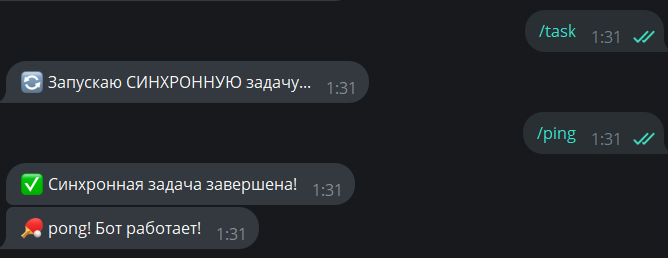

Что мы видим в этом примере:

1. Когда пользователь отправляет /task, бот:

 - Немедленно отвечает "🔄 Запускаю СИНХРОННУЮ задачу..."

 - Вызывает sync_long_task(), которая содержит time.sleep(5) - это полностью блокирует весь бот на 5 секунд

 - Все остальные запросы (например, /ping) в эти 5 секунд не обрабатываются. То есть, если отправить /ping во время выполнения /task, бот не ответит сразу, ответ придёт только после завершения синхронной задачи

2. Только после завершения sleep бот отправляет результат и становится снова доступным

In [ ]:
# Инициализация экземпляра бота с токеном API Telegram
# ВНИМАНИЕ: В реальных проектах используйте переменные окружения для токена!
bot = Bot(token="7921200166:AAH33mgwGg3mt8wwE_p384vB9y8-c-LgoGY")
dp = Dispatcher()  # Создаем диспетчер для обработки входящих сообщений

# Асинхронная функция с долгой операцией
async def async_long_task():
    print("⏳ Начало АСИНХРОННОЙ задачи (5 сек)")
    # Неблокирующая задержка - event loop может выполнять другие задачи
    # Обратите внимание: реальное время ожидания 10 сек, а в описании 5 сек
    await asyncio.sleep(10)  # Рекомендуется выравнивать время в описании и коде
    return "✅ Асинхронная задача завершена!"

# Обработчик команды /start
@dp.message(Command("start"))
async def send_welcome(message: types.Message):
    # Отправка многострочного сообщения с помощью тройных кавычек
    await message.answer(
        "Привет! Попробуй команды:\n"
        "/atask - асинхронная задача (5 сек)\n"
        "/ping - проверка работы бота"
    )

# Обработчик команды /atask (правильный асинхронный подход)
@dp.message(Command("atask"))
async def handle_async_task(message: types.Message):
    await message.answer("🌀 Запускаю АСИНХРОННУЮ задачу...")

    # Правильное асинхронное выполнение с await
    result = await async_long_task()  # Event loop свободен во время ожидания

    await message.answer(result)  # Отправка результата после выполнения

# Обработчик команды /ping для проверки отзывчивости
@dp.message(Command("ping"))
async def handle_ping(message: types.Message):
    # Мгновенный ответ для проверки доступности бота
    await message.answer("🏓 pong! Бот работает!")

# Основная асинхронная функция для запуска бота
async def main():
    # Запускаем процесс long polling с интервалом опроса 1 сек (по умолчанию)
    await dp.start_polling(bot)

# Блок запуска для Jupyter/Google Colab и обычных скриптов
if __name__ == '__main__':
    try:
        # Стандартный запуск для Python 3.7+
        asyncio.run(main())
    except RuntimeError:
        # Обход ограничений для сред с уже запущенным event loop
        import nest_asyncio
        nest_asyncio.apply()  # Применяем патч для Colab/Jupyter
        asyncio.get_event_loop().run_until_complete(main())

/usr/local/lib/python3.11/dist-packages/aiohttp/connector.py:292: RuntimeWarning: coroutine 'main' was never awaited
  self._factory = functools.partial(ResponseHandler, loop=loop)


⏳ Начало АСИНХРОННОЙ задачи (5 сек)
⏳ Начало АСИНХРОННОЙ задачи (5 сек)


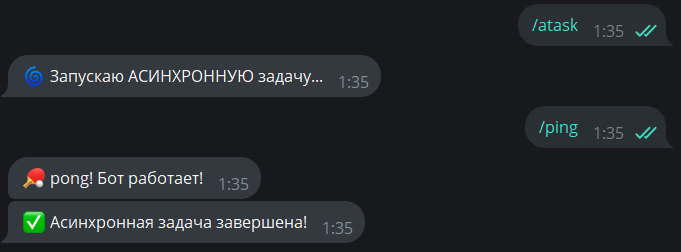

Что мы видим в этом примере:

1. При вызове /atask:

 - Бот сразу отвечает "Запускаю асинхронно..."

 - Начинается выполнение async_long_task()

 - Бот продолжает обрабатывать другие сообщения во время ожидания

2. Поведение при проверке
 - Если отправить /ping во время выполнения /atask, бот ответит "pong!" сразу

 - Через 10 секунд придёт результат асинхронной задачи

## Пример 6

Рассмотрим в этом примере получение данных о погоде из 10 городов. Затем сравним временные затраты при асинхронном подходе и синхронном.

Будем отправлять get-запросы в сервис http://api.openweathermap.org, в котором можно бесплатно зарегистрироваться и получить токен для выполнения запросов. Токен будет активирован через 2 часа после регистрации.

In [ ]:
# Импорт библиотеки для выполнения HTTP-запросов
import requests
# Импорт модуля для работы со временем (замер скорости выполнения)
import time

# Синхронная функция для получения данных о погоде
def get_weather(city):
    """
    Получает текущую погоду для указанного города через OpenWeatherMap API
    Проблема: синхронный запрос блокирует выполнение всей программы
    """

    # Базовый URL API OpenWeatherMap
    url = 'http://api.openweathermap.org/data/2.5/weather'

    # Параметры запроса:
    # q - название города
    # APPID - ключ API (в реальных проектах НЕ храните в коде!)
    # units=metric - получение данных в градусах Цельсия
    # lang=ru - локализация на русский язык
    params = {
        'q': city,
        'APPID': '7666d05625e5c2edfea595721e0e51e2',
        'units': 'metric',
        'lang': 'ru'
    }

    try:
        # Выполнение GET-запроса (блокирующая операция)
        response = requests.get(url=url, params=params)
        response.raise_for_status()  # Проверка на HTTP-ошибки

        # Конвертация ответа в JSON-формат
        weather_data = response.json()

        # Извлечение данных из ответа
        temperature = weather_data['main']['temp']
        description = weather_data['weather'][0]['description']
        print(f"Погода в {city}: {temperature}°C, {description.capitalize()}")

    except requests.exceptions.RequestException as e:
        print(f"Ошибка запроса для {city}: {str(e)}")
    except KeyError:
        print(f"Некорректный ответ API для {city}")

# Основная функция обработки
def main(list_cities):
    """
    Последовательно обрабатывает города один за другим
    Недостаток: города обрабатываются последовательно, а не параллельно
    """
    for city in list_cities:
        get_weather(city)  # Каждый вызов блокирует выполнение

# Список городов для проверки
cities = [
    'Moscow', 'St. Petersburg', 'Rostov-on-Don', 'Kaliningrad',
    'Vladivostok', 'Minsk', 'Beijing', 'Delhi', 'Istanbul', 'Tokyo'
]

# Замер времени выполнения
start = time.time()

# Запуск основного скрипта
main(cities)

# Вывод общего времени выполнения
print(f"\nОбщее время выполнения: {time.time() - start:.2f} секунд")

Погода в Moscow: 3.05°C, Пасмурно
Погода в St. Petersburg: 5.08°C, Ясно
Погода в Rostov-on-Don: 8.29°C, Пасмурно
Погода в Kaliningrad: 7.03°C, Переменная облачность
Погода в Vladivostok: 6.1°C, Пасмурно
Погода в Minsk: 5.53°C, Небольшая облачность
Погода в Beijing: 8.94°C, Ясно
Погода в Delhi: 32.05°C, Мгла
Погода в Istanbul: 10.4°C, Переменная облачность
Погода в Tokyo: 18.4°C, Ясно

Общее время выполнения: 0.26 секунд


Что делает этот код:
1. Функция get_weather(city)

 - Отправляет HTTP-запрос к API OpenWeatherMap.

 - requests.get() — синхронный запрос (блокирует выполнение программы, пока не получит ответ).

 - Выводит погоду для города в формате: "Город: тип_погоды".

2. Функция main(list_cities)

 - Последовательно перебирает список городов.

 - Для каждого города вызывает get_weather(city).

 - Поскольку запросы выполняются последовательно, каждый следующий город ждёт завершения предыдущего.

3. Измерение времени выполнения

 - start = time.time() — фиксирует время начала.

 - После выполнения всех запросов выводит общее время работы скрипта.

Итог:

 - Все запросы выполняются один за другим.

 - Если один запрос занимает 0.5 секунды, то 10 городов обработаются за ~5 секунд.

 - Проблема: пока идёт запрос, программа "висит" и не может делать ничего другого.

In [ ]:
# Импорт библиотеки для работы с временными замерами
import time
# Импорт асинхронных библиотек
import asyncio
from aiohttp import ClientSession  # Асинхронный HTTP-клиент

# Асинхронная функция для получения данных о погоде
async def get_weather(city):
    """
    Асинхронно получает данные о погоде через OpenWeatherMap API
    Важно: Используйте aiohttp вместо requests для асинхронных запросов!
    """

    # Базовый URL API
    url = 'http://api.openweathermap.org/data/2.5/weather'

    # Параметры запроса (ВНИМАНИЕ: API-ключ в коде - небезопасно!)
    params = {
        'q': city,
        'APPID': '7666d05625e5c2edfea595721e0e51e2',
        'units': 'metric',    # Получение данных в градусах Цельсия
        'lang': 'ru'          # Локализация на русский язык
    }

    try:
        # Создание асинхронной HTTP-сессии
        async with ClientSession() as session:
            # Выполнение асинхронного GET-запроса
            async with session.get(url, params=params) as response:
                response.raise_for_status()  # Проверка HTTP-статуса
                weather_data = await response.json()  # Чтение JSON

                # Извлечение данных из ответа
                temp = weather_data['main']['temp']
                description = weather_data['weather'][0]['description']
                print(f"Погода в {city}: {temp}°C, {description.capitalize()}")

    except Exception as e:
        print(f"Ошибка для {city}: {str(e)}")

# Основная асинхронная функция
async def main(cities_list):
    """
    Создает и запускает задачи для каждого города
    """
    # Создание задач для каждого города
    tasks = [
        asyncio.create_task(get_weather(city))
        for city in cities_list
    ]

    # Ожидание выполнения всех задач
    await asyncio.gather(*tasks)

# Список городов для проверки
cities = [
    'Moscow', 'St. Petersburg', 'Rostov-on-Don', 'Kaliningrad',
    'Vladivostok', 'Minsk', 'Beijing', 'Delhi', 'Istanbul', 'Tokyo'
]

# Замер времени выполнения
start_time = time.time()

# Запуск асинхронного приложения
if __name__ == '__main__':
    asyncio.run(main(cities))  # Стандартный запуск для Python

# Вывод общего времени выполнения
print(f"\nОбщее время выполнения: {time.time() - start_time:.2f} сек.")

# Улучшения и комментарии:
# 1. Замена requests на aiohttp для асинхронных запросов
# 2. Добавлена обработка ошибок
# 3. Использованы параметры для локализации и единиц измерения
# 4. Правильный запуск через asyncio.run()

# Важные замечания:
# - API-ключ должен храниться в переменных окружениях
# - Для продакшена добавьте:
#   - Ограничение количества одновременных запросов
#   - Кеширование результатов
#   - Ретраи при ошибках
#   - Логирование
#   - Прокси-поддержку

# Пример ограничения количества одновременных запросов:
# from aiocode import limit
# @limit(5)  # Не более 5 одновременных запросов
# async def get_weather(city):
#     ...

Погода в Kaliningrad: 7.03°C, Переменная облачность
Погода в Beijing: 8.94°C, Ясно
Погода в Vladivostok: 6.1°C, Пасмурно
Погода в Delhi: 32.05°C, Мгла
Погода в Minsk: 5.53°C, Небольшая облачность
Погода в Moscow: 2.79°C, Пасмурно
Погода в Istanbul: 10.4°C, Переменная облачность
Погода в Tokyo: 18.4°C, Ясно
Погода в Rostov-on-Don: 8.29°C, Пасмурно
Погода в St. Petersburg: 4.08°C, Ясно

Общее время выполнения: 0.03 сек.


1. Асинхронная функция get_weather(city)

 - Использует ClientSession() из aiohttp для асинхронных HTTP-запросов.

 - async with session.get() — неблокирующий запрос (программа не "зависает" в ожидании ответа).

 - await response.json() — приостанавливает только текущую корутину, а не весь поток.

2. Функция main(list_cities)

 - Создаёт список задач (tasks) — по одной на каждый город.

 - asyncio.create_task() — запускает корутину в фоне.

 - await asyncio.wait(tasks) — ждёт завершения всех задач.

3. Измерение времени выполнения

 - asyncio.run(main(cities)) — запускает асинхронный event loop.

 - Выводит общее время, которое заняла обработка всех городов.

Итог:

- Запросы выполняются параллельно (конкурентно).

- Если один запрос занимает 0.5 секунды, 10 городов обработаются за ~0.5–1 секунду (а не 5 секунд, как в синхронной версии).

- Преимущество: программа не блокируется на ожидании ответа от API.

Мы видим, что выполнение синхронного кода занимает больше времени. Это происходит потому, что обработка запросов происходит последовательно, в отличие от асинхронного кода.

## Пример 7

Рассмотрим ещё один пример различия синхронного и асинхронного кода. Напишем код для парсера, с помощью которого можно получать последние новости с сайта и ссылки на них с сайта РБК. Замерим время выполнения кода и сравним показатели для синхронного и асинхронного подхода.

In [ ]:
# Импорт необходимых библиотек
import time  # Для замера времени выполнения
import requests  # Для выполнения HTTP-запросов
from bs4 import BeautifulSoup  # Для парсинга HTML
from fake_useragent import UserAgent  # Для генерации случайных User-Agent
from urllib.parse import urljoin  # Для обработки относительных ссылок

def fetch_news(url):
    """
    Синхронная функция для получения HTML-контента страницы
    Args:
        url (str): URL целевой страницы
    Returns:
        str: HTML-контент или None при ошибке
    """
    ua = UserAgent()  # Инициализация генератора User-Agent
    headers = {'User-Agent': ua.random}  # Случайный User-Agent для каждого запроса

    try:
        # Выполняем GET-запрос с таймаутом 10 секунд
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()  # Проверяем статус ответа (4xx/5xx ошибки)
        return response.text  # Возвращаем HTML-контент

    except requests.exceptions.RequestException as e:
        # Обрабатываем основные ошибки запросов
        print(f"Ошибка при запросе к {url}: {e}")
        return None
    except Exception as e:
        # Общий обработчик других исключений
        print(f"Непредвиденная ошибка: {e}")
        return None

def parse_rbc_news():
    """
    Парсинг главной страницы RBC.ru для получения последних новостей
    Returns:
        list: Список словарей с заголовками и ссылками на новости
    """
    base_url = 'https://www.rbc.ru/'  # Базовый URL сайта
    html = fetch_news(base_url)  # Получаем HTML-контент

    if not html:
        return []  # Возвращаем пустой список при ошибке

    soup = BeautifulSoup(html, 'html.parser')  # Инициализируем парсер
    news_list = []  # Список для хранения результатов

    # Поиск новостных блоков (основной и альтернативный селекторы)
    news_blocks = soup.find_all('a', class_='news-feed__item') or \
                  soup.find_all('div', class_='news-feed__item')

    # Обрабатываем первые 15 найденных блоков
    for block in news_blocks[:15]:
        try:
            # Извлечение заголовка новости
            title_element = block.find('span', class_='news-feed__item__title') or \
                            block.find('span', class_='item__title')

            # Извлечение и обработка ссылки
            relative_link = block.get('href')
            absolute_link = urljoin(base_url, relative_link) if relative_link else None

            if title_element and absolute_link:
                news_list.append({
                    'title': title_element.get_text(strip=True),  # Чистый текст заголовка
                    'url': absolute_link  # Абсолютный URL
                })
        except AttributeError as e:
            print(f"Ошибка парсинга блока: {e}")
            continue

    return news_list

def main():
    """
    Основная функция для управления процессом парсинга и вывода результатов
    """
    print("Загружаем последние новости с RBC.ru...\n")
    start_time = time.time()  # Засекаем время начала

    news = parse_rbc_news()  # Получаем список новостей

    # Вывод результатов
    if not news:
        print("❌ Не удалось получить новости. Возможные причины:")
        print("- Изменение структуры сайта")
        print("- Проблемы с интернет-соединением")
        print("- Ограничение доступа (анти-парсинг)")
    else:
        print(f"✅ Получено {len(news)} новостей:\n")
        for i, item in enumerate(news, 1):
            print(f"{i}. {item['title']}")
            print(f"   🔗 {item['url']}\n")

    # Вывод времени выполнения
    print(f"Время выполнения: {time.time() - start_time:.2f} секунд")

if __name__ == "__main__":
    main()  # Запуск основной функции

Загружаем последние новости с RBC.ru...

✅ Получено 15 новостей:

1. Курс евро на 26 апреляEUR ЦБ: 94,36(-0,35)
   🔗 https://quote.ru/ticker/72383

2. Курс доллара на 26 апреляUSD ЦБ: 82,65(-0,2)
   🔗 https://quote.ru/ticker/72413

3. «Ливерпуль» в 20-й раз стал чемпионом Англии
   🔗 https://www.rbc.ru/sport/27/04/2025/680e5e169a79479fe76763a8?from=newsfeed

4. Израиль сообщил об ударе по складу с ракетами «Хезболлы» в Бейруте
   🔗 https://www.rbc.ru/rbcfreenews/680e60969a79476557f7186a?from=newsfeed

5. Лавров напомнил позицию Путина о прекращении огня на Украине
   🔗 https://www.rbc.ru/rbcfreenews/680e600e9a7947211ade63db?from=newsfeed

6. n-tv сообщил, кто станет министром в кабинете Мерца
   🔗 https://www.rbc.ru/politics/27/04/2025/680e5cf19a79479d6b7fb5a3?from=newsfeed

7. Суд в Москве арестовал обвиняемого в убийстве генерала Москалика
   🔗 https://www.rbc.ru/politics/27/04/2025/680e61629a79476fec638c2a?from=newsfeed

8. Жулин заявил, что пропустит отбор на Олимпиаду из-за резких

Поясним, что делает этот код.

1. Функция fetch_news():

 - Создает объект UserAgent для генерации случайных заголовков

 - Формирует headers для HTTP-запроса с User-Agent и языковыми настройками

 - Выполняет GET-запрос к указанному URL с таймаутом 10 секунд

 - Проверяет статус ответа (response.raise_for_status())

 - Возвращает HTML-код страницы или None при ошибке

2. Функция parse_gov_news():

 - Получает HTML-код страницы через fetch_news()

 - Создает объект BeautifulSoup для парсинга

 - Находит все новостные блоки по классу 'headline'

 - Для каждого блока (максимум 15) извлекает: Заголовок (span.headline_title_link), Ссылку (a.headline__link), Дату (time), Категорию (ссылки с '/rugovclassifier/'), Краткое описание (span.headline_lead), Изображение (img.headline_photo)

 - Преобразует относительные ссылки в абсолютные через urljoin

 - Формирует список словарей с информацией о новостях

3. Функция main():

 - Замеряет время начала выполнения

 - Получает список новостей через parse_gov_news()

 - Выводит результат в удобном формате с:

 - Выводит время выполнения



In [ ]:
# Импорт необходимых библиотек
import time  # Для замера времени выполнения
import aiohttp  # Асинхронный HTTP-клиент
from bs4 import BeautifulSoup  # Парсинг HTML/XML
from fake_useragent import UserAgent  # Генерация случайных User-Agent
from urllib.parse import urljoin  # Обработка относительных URL

async def fetch_news(session, url):
    """
    Асинхронно получает HTML-контент страницы
    Args:
        session (aiohttp.ClientSession): Асинхронная HTTP-сессия
        url (str): URL для запроса
    Returns:
        str: HTML-контент или None при ошибке
    """
    ua = UserAgent()  # Инициализация генератора User-Agent
    headers = {'User-Agent': ua.random}  # Случайный заголовок для каждого запроса

    try:
        # Асинхронный GET-запрос с таймаутом 10 секунд
        async with session.get(url, headers=headers, timeout=10) as response:
            if response.status == 200:  # Проверка успешного статуса
                return await response.text()  # Чтение контента с освобождением event loop
            else:
                # Логирование HTTP-ошибок
                print(f"Ошибка {response.status} при запросе к {url}")
                return None
    except Exception as e:
        # Перехват всех исключений (таймаут, сетевые ошибки и т.д.)
        print(f"Ошибка при запросе: {e}")
        return None

async def parse_rbc_news():
    """
    Основная функция парсинга новостей RBC
    Returns:
        list: Список словарей с заголовками и ссылками
    """
    base_url = 'https://www.rbc.ru/'  # Базовый URL сайта

    # Создание асинхронной HTTP-сессии
    async with aiohttp.ClientSession() as session:
        html = await fetch_news(session, base_url)  # Асинхронный запрос
        if not html:
            return []  # Возвращаем пустой список при ошибке

        # Инициализация парсера с lxml (требует установки lxml)
        soup = BeautifulSoup(html, 'lxml')
        news_list = []  # Контейнер для результатов

        # Поиск новостных блоков (основной и альтернативный селекторы)
        news_blocks = soup.find_all('a', class_='news-feed__item') or \
                     soup.find_all('div', class_='news-feed__item')

        # Обработка первых 15 элементов
        for block in news_blocks[:15]:
            try:
                # Поиск заголовка в разных вариантах верстки
                title = (block.find('span', class_='news-feed__item__title') or
                         block.find('span', class_='item__title'))

                # Обработка ссылок для разных типов блоков
                link = block.get('href')
                if not link and block.name == 'div':  # Если блок - div
                    parent_link = block.find_parent('a')  # Ищем родительскую ссылку
                    link = parent_link.get('href') if parent_link else None

                # Конвертация относительных ссылок в абсолютные
                if link and not link.startswith(('http', '//')):
                    link = urljoin(base_url, link)

                if title and link:
                    news_list.append({
                        'title': title.get_text(strip=True),  # Чистый текст
                        'url': link  # Полный URL
                    })
            except Exception as e:
                print(f"Ошибка обработки блока: {str(e)}")
                continue  # Продолжаем при ошибках парсинга

        return news_list

async def main():
    """Главная управляющая функция"""
    print("Загружаем последние новости с RBC.ru...\n")
    start_time = time.time()  # Старт замера времени

    news = parse_rbc_news()  # Асинхронный вызов парсера

    # Вывод результатов
    if not news:
        print("""❌ Не удалось получить новости. Причины:
- Изменение структуры сайта
- Проблемы с подключением
- Блокировка запросов""")
    else:
        print(f"✅ Успешно получено {len(news)} новостей:\n")
        for i, item in enumerate(news, 1):
            print(f"{i}. {item['title']}")
            print(f"   🔗 {item['url']}\n")

    # Вывод времени выполнения
    print(f"Общее время выполнения: {time.time() - start_time:.2f} сек.")

# Запуск в средах с активным event loop (Jupyter/Colab)
if __name__ == "__main__":
    # Обычный запуск для Python скриптов:
    # import asyncio
    # asyncio.run(main())

    # Для Google Colab/Jupyter:
    await main()

# Рекомендации по улучшению:
# 1. Добавить кеширование (например, redis)
# 2. Реализовать ретраи при ошибках
# 3. Ограничить количество одновременных запросов
# 4. Добавить прокси-поддержку
# 5. Сохранять результаты в БД
# 6. Реализовать проверку дублей

# Пример ограничения запросов:
# from aiocode import limit
# @limit(5)  # Не более 5 одновременных запросов
# async def fetch_news(...):

Загружаем последние новости с RBC.ru...

✅ Успешно получено 15 новостей:

1. Курс евро на 26 апреляEUR ЦБ: 94,36(-0,35)
   🔗 https://quote.ru/ticker/72383

2. Курс доллара на 26 апреляUSD ЦБ: 82,65(-0,2)
   🔗 https://quote.ru/ticker/72413

3. Число жертв взрыва в порту Ирана возросло до 40
   🔗 https://www.rbc.ru/rbcfreenews/680e66e09a7947ed0b95a1a2?from=newsfeed

4. «Ливерпуль» в 20-й раз стал чемпионом Англии
   🔗 https://www.rbc.ru/sport/27/04/2025/680e5e169a79479fe76763a8?from=newsfeed

5. Израиль сообщил об ударе по складу с ракетами «Хезболлы» в Бейруте
   🔗 https://www.rbc.ru/rbcfreenews/680e60969a79476557f7186a?from=newsfeed

6. Лавров напомнил позицию Путина о прекращении огня на Украине
   🔗 https://www.rbc.ru/rbcfreenews/680e600e9a7947211ade63db?from=newsfeed

7. n-tv сообщил, кто станет министром в кабинете Мерца
   🔗 https://www.rbc.ru/politics/27/04/2025/680e5cf19a79479d6b7fb5a3?from=newsfeed

8. Суд в Москве арестовал обвиняемого в убийстве генерала Москалика
   🔗 https:

Как мы видим, асинхронный метод так же позволяет обрабатывать запрос быстрее.

## Пример 8



Асинхронный парсинг позволяет одновременно обрабатывать несколько веб-ресурсов, значительно ускоряя сбор данных. Сегодня мы разберем, как реализовать параллельный сбор новостей с трех источников:
1. Официальный сайт Правительства РФ
2. РИА Новости (раздел "Мир")
3. Коммерсантъ

### **Преимущества перед синхронным подходом:**
1. Высокая производительность
2. Эффективное использование ресурсов
3. Возможность обработки множества источников одновременно

### **Ключевые элементы в Python данного примера:**
- `async/await` - синтаксис для работы с корутинами
- `asyncio` - библиотека для работы с асинхронным кодом
- `aiohttp` - асинхронный HTTP-клиент

In [ ]:
### Установка зависимостей

!pip install -q --upgrade aiohttp beautifulsoup4 lxml
# - aiohttp: асинхронные HTTP-запросы
# - beautifulsoup4: парсинг HTML/XML
# - lxml: быстрый XML-парсер (альтернатива html.parser)

# lxml требует установки системных зависимостей:
#   Ubuntu/Debian: sudo apt-get install libxml2-dev libxslt-dev
#   Windows: установите binary wheels через pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.0 MB/s eta 0:00:00


In [ ]:
# Импорт необходимых библиотек
import nest_asyncio  # Для работы asyncio в Jupyter Notebook
import os  # Для работы с файловой системой
nest_asyncio.apply()  # Применяем патч для обхода ограничений Jupyter

import asyncio  # Для асинхронного программирования
from aiohttp import ClientSession  # Асинхронный HTTP-клиент
from bs4 import BeautifulSoup  # Парсинг HTML/XML
from urllib.parse import urljoin  # Для создания абсолютных URL из относительных

# Асинхронная функция для выполнения HTTP-запроса
async def fetch(url, session):
    # Устанавливаем заголовки, чтобы имитировать браузер
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    async with session.get(url, headers=headers) as response:  # Отправляем GET-запрос
        return await response.text()  # Возвращаем HTML-контент

# Парсер для сайта government.ru
async def parse_government_ru(session):
    url = "http://government.ru/news/"
    try:
        html = await fetch(url, session)  # Получаем HTML
        soup = BeautifulSoup(html, 'lxml')  # Создаем объект для парсинга
        news = []
        # Ищем все элементы с новостями по CSS-селектору
        for item in soup.select('a.headline__link')[:]:
            title_element = item.select_one('.headline_title_link')  # Заголовок новости
            if not title_element:
                continue  # Пропускаем если нет заголовка

            title = title_element.text.strip()  # Извлекаем текст заголовка
            relative_link = item.get('href')  # Относительная ссылка
            full_link = urljoin(url, relative_link)  # Собираем абсолютный URL

            news.append((title, full_link))  # Добавляем в список
        return news
    except Exception as e:
        print(f"Error parsing government.ru: {str(e)}")
        return []  # Возвращаем пустой список при ошибке

# Парсер для сайта ria.ru
async def parse_ria_world(session):
    url = "https://ria.ru/world/"
    try:
        html = await fetch(url, session)
        soup = BeautifulSoup(html, 'lxml')
        news = []
        # Ищем элементы новостей (обновленный селектор)
        for item in soup.select('.list-item')[:]:
            title = item.select_one('.list-item__title').text.strip()  # Извлекаем заголовок
            link = item.select_one('.list-item__content a')['href']  # Ссылка
            news.append((title, link))
        return news
    except Exception as e:
        print(f"Error parsing ria.ru: {str(e)}")
        return []

# Парсер для сайта kommersant.ru
async def parse_kommersant(session):
    url = "https://www.kommersant.ru/"
    try:
        html = await fetch(url, session)
        soup = BeautifulSoup(html, 'lxml')
        news = []
        # Ищем первые 5 элементов новостей
        for item in soup.select('.uho')[:5]:
            title = item.select_one('.uho__link').text.strip()
            link = urljoin(url, item.select_one('.uho__link')['href'])  # Собираем абсолютный URL
            news.append((title, link))
        return news
    except Exception as e:
        print(f"Error parsing kommersant: {str(e)}")
        return []

# Главная асинхронная функция
async def main():
    async with ClientSession() as session:  # Создаем сессию
        # Параллельно запускаем все парсеры
        results = await asyncio.gather(
            parse_government_ru(session),
            parse_ria_world(session),
            parse_kommersant(session)
        )
        # Формируем итоговый словарь с результатами
        return {
            "government.ru": results[0],
            "ria.ru": results[1],
            "kommersant": results[2]
        }

# Запуск асинхронного кода в Jupyter Notebook
data = await main()

# Сохранение результатов в текстовый файл
with open('last-news.txt', 'w', encoding='utf-8') as f:
    for source, news in data.items():
        f.write(f"\n{source.upper()}:\n")  # Заголовок источника
        # Записываем каждую новость с нумерацией
        for idx, (text, link) in enumerate(news, 1):
            f.write(f"{idx}. {text}\nСсылка: {link}\n\n")

# Вывод результатов в консоль
for source, news in data.items():
    print(f"\n{source.upper()}:")
    for idx, (text, link) in enumerate(news, 1):
        print(f"{idx}. {text}")
        print(f"   Ссылка: {link}")


GOVERNMENT.RU:
1. Михаил Мишустин поздравил российских парламентариев с профессиональным праздником
   Ссылка: http://government.ru/news/54873/
2. Правительство увеличило размеры стипендий имени В.С.Черномырдина и Е.М.Примакова
   Ссылка: http://government.ru/news/54888/
3. Решения, принятые на заседании Правительства 24 апреля 2025 года
   Ссылка: http://government.ru/news/54883/
4. Правительство выделило дополнительные средства на оказание помощи пострадавшим жителям Курской области
   Ссылка: http://government.ru/news/54867/
5. Дмитрий Чернышенко провёл рабочую встречу с главой Республики Крым Сергеем Аксёновым
   Ссылка: http://government.ru/news/54886/
6. Денис Мантуров посетил промышленные предприятия Москвы
   Ссылка: http://government.ru/news/54885/
7. Дмитрий Чернышенко провёл заседание оргкомитета по подготовке к 100-летию «Артека» и оценил объекты строительства
   Ссылка: http://government.ru/news/54884/
8. Дмитрий Патрушев: В 2024 году на геологоразведку было направлено бо

----

Сделаем вывод, почему использование асинхронного метода лучше, особенно, если речь идёт о Telegram-ботах и других решениях, которые предполагают обработку сразу нескольких запросов.

1. Масштабируемость: можно обрабатывать тысячи одновременных запросов

2. Отзывчивость: бот не "зависает" при долгих операциях

3. Эффективность: нет простоя во время ожидания ответов от API/БД, интерфейс не "зависает" во время долгих операций

Как работает асинхронность "под капотом"?
Когда корутина встречает await, она возвращает управление в event loop. Event loop переключается на выполнение других готовых задач. Когда операция (например, sleep) завершается, корутина продолжает работу.

Это похоже на работу шефа в ресторане:

 - Синхронный: шеф лично готовит каждый заказ от начала до конца

 - Асинхронный: шеф распределяет задачи между поварами и контролирует процесс.



# Асинхронное программирование. Углублённая теория

Модуль asyncio предоставляет инструменты для создания асинхронных/параллельных приложений с использованием сопрограмм.

Coroutine (корутины), или сопрограммы — это блоки кода, которые работают асинхронно, то есть по очереди.


Модуль `asyncio` предоставляет инструменты для создания асинхронных/параллельных приложений с использованием сопрограмм.

Coroutine (корутины), или сопрограммы — это блоки кода, которые работают асинхронно, то есть по очереди.

В отличие от функций, сопрограммы создаются при помощи выражения `async def`:

    async def async_func():
       ...

Запуск сопрограмм, которые должны или могут ждать каких-то результатов (например, ответа сервера с результатами запроса) запускаются оператором `await`.

Ключевое слово `await` можно использовать только в теле сопрограммы. Вызов `await` в другом месте спровоцирует ошибку.

Функция `asyncio.run()` запускает цикл событий в асинхронном коде. Её следует использовать в качестве основной точки входа для программ с использованием модуля `asyncio`, а в идеале функцию `asyncio.run()` следует вызывать только один раз.

Запуск сопрограмм можно осуществлять через создание и планирование задач (Task) при помощи функции `asyncio.create_task()`. Задачи так же запускаем оператором `await`. Задачи используются для планирования параллельного выполнения сопрограмм.

Задачи после создания являются объектами класса `Task()` и имеют некоторые методы, такие как:

Метод | Описание
---|---
Task.done() | Проверка выполнения задачи
Task.result() | Результат выполнения задачи
Task.get_name() | Получить имя задачи
Task.set_name() | Установить имя задачи
Task.cancel() | Отмена задачи
и тд

Итак, объект `Task` - это сопрограмма, которая планируется для выполнения в будущем, как только это станет возможным. Но есть и вторая сущность - объект уже запущенной сопрограммы с еще неполученными/промежуточными результатами, который является частью `Task` и именуется как `Future`. Нет необходимости создавать объекты `Future` на уровне приложения. В основном, эти объекты создаются автоматически, при вызове функций или методов, предоставляемыми асинхронными API модулей.

Функция `wait()` модуля `asyncio` одновременно запускает `awaitable`-объекты (преимущественно задачи Task) из переданного множества aws и производит блокировку выполнения программы до выполнения условия, указанного в аргументе `return_when`.

    await asyncio.wait(aws, timeout, return_when)

        aws - список объектов ожидания;
        timeout - максимальное количество секунд ожидания;
        return_when - условие остановки и возвращения результата.

Аргумент `return_when` указывает, при каких условиях функция `asyncio.wait()` должна вернуть результат. Это должна быть одна из следующих констант:

Константа | Описание
--- | ---
`asyncio.FIRST_COMPLETED` | Функция вернет результат, когда любой объект ожидания завершится или будет отменен
`asyncio.FIRST_EXCEPTION` | Функция вернет результат, когда любой объект ожидания завершится созданием исключения (ошибкой)
`asyncio.ALL_COMPLETED` | Функция вернет результат, когда все объекты ожидания завершатся или будут отменены

Возвращает функция `wait()` кортеж из 2 множеств `Task`/`Future` в виде (done, pending). Множество done - это выполненные задачи, а pending - задачи в ожидании.

Покажем, как это работает на приере кода.

In [ ]:
# Импорт необходимых библиотек
import random  # Для генерации случайных чисел
from datetime import datetime  # Для работы с временными метками
import asyncio  # Для асинхронного программирования

# Асинхронная функция (сопрограмма) для демонстрации работы с задержками
async def print_message(number, delay):
    """Сопрограмма, которая выводит сообщение после задержки"""
    # Выводим стартовое сообщение с текущим временем и параметрами задачи
    print(f"[{datetime.now().time()}] Задача {number}: Начало выполнения (ожидание {delay} сек)")

    # Асинхронное ожидание - передаем управление обратно в цикл событий
    # В это время могут выполняться другие задачи
    await asyncio.sleep(delay)

    # Сообщение после завершения задержки
    print(f"[{datetime.now().time()}] Задача {number}: Сообщение после задержки")
    return f"Результат задачи {number}"  # Возвращаем результат выполнения

# Основная асинхронная функция
async def main():
    """Основная сопрограмма, управляющая выполнением задач"""
    print(f"[{datetime.now().time()}] Начало работы main()")

    # Создаем 5 задач с разными параметрами:
    # - i: номер задачи (1-5)
    # - random.uniform(1, 3): случайная задержка от 1 до 3 секунд
    tasks = [
        asyncio.create_task(print_message(i, random.uniform(1, 3)))
        for i in range(1, 6)
    ]

    # Добавляем имена задачам для удобства отслеживания
    for i, task in enumerate(tasks, 1):
        task.set_name(f"Task-{i}")  # Именуем задачи как Task-1, Task-2 и т.д.

    # Запускаем все задачи и ждем завершения ПЕРВОЙ из них
    # return_when=asyncio.FIRST_COMPLETED - режим ожидания первой завершенной задачи
    done, pending = await asyncio.wait(
        tasks,
        return_when=asyncio.FIRST_COMPLETED
    )

    # Выводим информацию о первой завершенной задаче
    print("\nПервая завершенная задача:")
    for task in done:  # done содержит завершенные задачи
        print(f"- {task.get_name()} вернула: {task.result()}")  # Получаем результат задачи

    # Запускаем ожидание для ВСЕХ ОСТАВШИХСЯ задач
    print("\nОжидаем завершения оставшихся задач...")
    done, pending = await asyncio.wait(pending)  # Теперь ждем все остальные задачи

    # Финальный отчет о статусе всех задач
    print("\nВсе задачи завершены:")
    for task in tasks:
        status = 'выполнена' if task.done() else 'не выполнена'
        print(f"- {task.get_name()}: {status}")
        if task.done():
            print(f"  Результат: {task.result()}")  # Показываем результаты выполненных задач

# Точка входа в программу
if __name__ == "__main__":
    print("--- Демонстрация работы asyncio ---")

    # ВНИМАНИЕ: В обычном Python-скрипте нельзя использовать await вне async функции
    # Этот код будет работать только в средах с уже запущенным циклом событий
    # (например, в Jupyter Notebook с примененным nest_asyncio.apply())
    # Для запуска в обычном скрипте используйте: asyncio.run(main())
    await main()  # Основная точка входа в асинхронное выполнение

--- Демонстрация работы asyncio ---
[18:05:15.736614] Начало работы main()
[18:05:15.736799] Задача 1: Начало выполнения (ожидание 1.999601751321813 сек)
[18:05:15.736847] Задача 2: Начало выполнения (ожидание 2.218999325669632 сек)
[18:05:15.736867] Задача 3: Начало выполнения (ожидание 1.7164334942424426 сек)
[18:05:15.736883] Задача 4: Начало выполнения (ожидание 2.7759037395603015 сек)
[18:05:15.736898] Задача 5: Начало выполнения (ожидание 2.503287898019339 сек)
[18:05:17.455633] Задача 3: Сообщение после задержки

Первая завершенная задача:
- Task-3 вернула: Результат задачи 3

Ожидаем завершения оставшихся задач...
[18:05:17.737654] Задача 1: Сообщение после задержки
[18:05:17.957202] Задача 2: Сообщение после задержки
[18:05:18.240842] Задача 5: Сообщение после задержки
[18:05:18.513492] Задача 4: Сообщение после задержки

Все задачи завершены:
- Task-1: выполнена
  Результат: Результат задачи 1
- Task-2: выполнена
  Результат: Результат задачи 2
- Task-3: выполнена
  Результат

Разберём более подробно, что делает этот код и что означает такой результат, который видим в выводе кодовой ячейки.

1. Сопрограмма print_message:

 - Принимает номер задачи и время задержки

 - Выводит сообщение о начале выполнения

 - Использует await asyncio.sleep() для неблокирующей задержки

 - Возвращает результат после задержки

2. Основная сопрограмма main:

 - Создает 5 задач с разными задержками

 - Задачам даются имена через set_name()

 - Использует asyncio.wait() с параметром FIRST_COMPLETED

 - Обрабатывает первую завершенную задачу

 - Затем ожидает завершения оставшихся задач

Ключевые моменты:

- asyncio.create_task() - создает задачу из сопрограммы

- await asyncio.wait() - ожидает выполнения задач

- task.done() - проверяет завершение задачи

- task.result() - получает результат задачи

- asyncio.run() - запускает главную сопрограмму